# Libraries and Functions

In [125]:
#Arrays and containers
import numpy as np
import pandas as pd

#Plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
import arviz as az

#Stats
from scipy import stats
from patsy import dmatrix
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pingouin import power_chi2
import pymc as pm
#import pytensor.tensor as pt
print('Running on PyMC v{}'.format(pm.__version__))




Running on PyMC v5.16.1


# Discrete Choice Experiment (Santa Fe Grill)

Before opening the restaurant, Santa Fe grill wants to gather data on the best approach to its restaurant. They hire a marketing company to run an discrete choice experiment.

They asked 200 participants of the area this ten times (changing the values in the options):


<center><img src="Eger_3.png" width = "600" height = '600'></center>

In [150]:
#Load data
#Adaptation of the ebook data by Felix Eggers, preferencelab.com. 
#I just changed the variable names to be about a Mexican restaurant
#Storage -> Menu size
#color -> location
#Screen size -> Restaurant size
#price -> price
# N = 200 respondents, S = 4 alternatives per set, C = 10 choice sets, N * S * C = 8000 observations
# N * S * C = 8000 observations
# Resp_id: respondant, Set_id: id of choice set C, 
# Alt_id: id of alternative (4 alternatives/options per set, the 4th is none)
#Selected: dummy relative to Alt_id i.e. 0 Alt_id not selected, 1 Alt_id was selected as the best option
data_DCE = pd.read_csv("SantaFe_DCE.csv") #DCE: discrete choice experiment
data_DCE.rename(columns={"None" : "None_ID", 
                        'Storage': 'Menu_size', #n dishes
                        'Color': 'Location', #Dowtown, Suburban, Riverside
                        'Screen.size': 'Rest_Size', #size (arbitrary units)
                        }, inplace=True)
data_DCE["Location"] = data_DCE["Location"].replace({"Silver": "Dowtown", "White": "Suburban", "Black": "Riverside", "0": "Irrelevant" })
#data_DCE["Ambience"] = data_DCE["Ambience"].replace({7: "Modern", 5: "Luxury", 6: "Traditional", 0: "Irrelevant" })

data_DCE.insert(4, "Selected_option", data_DCE.loc[:, "Selected"]*data_DCE.loc[:, "Alt_id"])
#data_DCE = data_DCE.astype({"Storage": "category", "Screen_size": "category", "Color": "category", "Price": "category"})
data_DCE.dtypes

Resp_id               int64
Set_id                int64
Alt_id                int64
Selected              int64
Selected_option       int64
None_ID               int64
Menu_size             int64
Rest_Size             int64
Location             object
Price                 int64
Storage_4GB           int64
Storage_8GB           int64
Screen.size_5inch     int64
Screen.size_6inch     int64
Color_black           int64
Color_white           int64
Price_79              int64
Price_99              int64
Price_119             int64
dtype: object

In [151]:
data_DCE["choice_id"] = data_DCE["Resp_id"].astype(str) + "_" + data_DCE["Set_id"].astype(str)
# reshape into wide format
data_DCE_wide = data_DCE.pivot(index="choice_id", columns="Alt_id", 
                               values=["Menu_size","Rest_Size", "Location", "Price", "Selected_option"])
#Flatten multi index
data_DCE_wide.columns = [f"{var}_{alt}" for var,alt in data_DCE_wide.columns]
data_DCE_wide.reset_index(inplace = True)

data_DCE_wide["Selected_option"] = data_DCE_wide[["Selected_option_1", "Selected_option_2", "Selected_option_3", "Selected_option_4"]].max(axis=1)

data_DCE_wide['Selected_option_1'] = data_DCE_wide['Selected_option_1'].apply(lambda x: 1 if isinstance(x, (int, float)) and x>0 else x)
data_DCE_wide['Selected_option_2'] = data_DCE_wide['Selected_option_2'].apply(lambda x: 1 if isinstance(x, (int, float)) and x>0 else x)
data_DCE_wide['Selected_option_3'] = data_DCE_wide['Selected_option_3'].apply(lambda x: 1 if isinstance(x, (int, float)) and x>0 else x)
data_DCE_wide['Selected_option_4'] = data_DCE_wide['Selected_option_4'].apply(lambda x: 1 if isinstance(x, (int, float)) and x>0 else x)
#cols_to_drop = ["Selected_option_1", "Selected_option_2", "Selected_option_3", "Selected_option_4"]
data_DCE_wide = data_DCE_wide.astype({"Selected_option": "int", 
                                      "Menu_size_1": "int",
                                      "Menu_size_2": "int",
                                      "Menu_size_3": "int",
                                      "Menu_size_4": "int",
                                      "Rest_Size_1": "int",
                                      "Rest_Size_2": "int",
                                      "Rest_Size_3": "int",
                                      "Rest_Size_4": "int",
                                      "Price_1": "int",
                                      "Price_2": "int",
                                      "Price_3": "int",
                                      "Price_4": "int"})
#data_DCE_wide = data_DCE_wide.drop(columns=cols_to_drop)

data_DCE_wide

,choice_id,Menu_size_1,Menu_size_2,Menu_size_3,Menu_size_4,Rest_Size_1,Rest_Size_2,Rest_Size_3,Rest_Size_4,Location_1,...,Location_4,Price_1,Price_2,Price_3,Price_4,Selected_option_1,Selected_option_2,Selected_option_3,Selected_option_4,Selected_option
0,100_1,4,8,16,0,5,7,6,0,Suburban,...,Irrelevant,79,99,119,0,0,0,1,0,3
1,100_10,8,16,4,0,5,7,6,0,Dowtown,...,Irrelevant,139,99,119,0,0,1,0,0,2
2,100_2,16,4,8,0,5,6,7,0,Riverside,...,Irrelevant,119,99,139,0,0,0,1,0,3
3,100_3,8,16,4,0,5,6,7,0,Dowtown,...,Irrelevant,79,119,139,0,1,0,0,0,1
4,100_4,8,16,4,0,5,6,7,0,Dowtown,...,Irrelevant,119,99,79,0,0,1,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,9_5,8,4,16,0,5,7,6,0,Suburban,...,Irrelevant,139,79,119,0,0,0,1,0,3
1996,9_6,16,8,4,0,5,7,6,0,Riverside,...,Irrelevant,79,119,99,0,1,0,0,0,1
1997,9_7,8,16,4,0,6,7,5,0,Riverside,...,Irrelevant,119,99,139,0,1,0,0,0,1
1998,9_8,8,4,16,0,6,7,5,0,Dowtown,...,Irrelevant,119,79,139,0,1,0,0,0,1


In [152]:
dummy_matrix = dmatrix('~ Menu_size_1 + Menu_size_2 + Menu_size_3 + Menu_size_4 + Rest_Size_1 + Rest_Size_2 + Rest_Size_3 + Rest_Size_4 + Location_1 + Location_2 + Location_3 + Location_4 + Price_1+ Price_2 + Price_3 + Price_4', 
                       data=data_DCE_wide)

# The result is a patsy.DesignMatrix object. You can convert it to a pandas DataFrame.
dummied_df = pd.DataFrame(dummy_matrix, columns=dummy_matrix.design_info.column_names)
dummied_df["Selected_option"] = data_DCE_wide["Selected_option"]
dummied_df

,Intercept,Location_1[T.Riverside],Location_1[T.Suburban],Location_2[T.Riverside],Location_2[T.Suburban],Location_3[T.Riverside],Location_3[T.Suburban],Menu_size_1,Menu_size_2,Menu_size_3,Menu_size_4,Rest_Size_1,Rest_Size_2,Rest_Size_3,Rest_Size_4,Price_1,Price_2,Price_3,Price_4,Selected_option
0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,4.0,8.0,16.0,0.0,5.0,7.0,6.0,0.0,79.0,99.0,119.0,0.0,3
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,8.0,16.0,4.0,0.0,5.0,7.0,6.0,0.0,139.0,99.0,119.0,0.0,2
2,1.0,1.0,0.0,0.0,1.0,0.0,0.0,16.0,4.0,8.0,0.0,5.0,6.0,7.0,0.0,119.0,99.0,139.0,0.0,3
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,8.0,16.0,4.0,0.0,5.0,6.0,7.0,0.0,79.0,119.0,139.0,0.0,1
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,8.0,16.0,4.0,0.0,5.0,6.0,7.0,0.0,119.0,99.0,79.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1.0,0.0,1.0,0.0,0.0,1.0,0.0,8.0,4.0,16.0,0.0,5.0,7.0,6.0,0.0,139.0,79.0,119.0,0.0,3
1996,1.0,1.0,0.0,0.0,0.0,0.0,1.0,16.0,8.0,4.0,0.0,5.0,7.0,6.0,0.0,79.0,119.0,99.0,0.0,1
1997,1.0,1.0,0.0,0.0,0.0,0.0,1.0,8.0,16.0,4.0,0.0,6.0,7.0,5.0,0.0,119.0,99.0,139.0,0.0,1
1998,1.0,0.0,0.0,0.0,1.0,1.0,0.0,8.0,4.0,16.0,0.0,6.0,7.0,5.0,0.0,119.0,79.0,139.0,0.0,1


### Discrete choice model (Bayesian Estimation)

In [154]:
N = dummied_df.shape[0]
observed = pd.Categorical(dummied_df["Selected_option"]).codes
alts_probs = ["1", "2", "3", "4"]
obs = range(N)

with pm.Model() as model_1:
    #Priors
    beta_menu_sz = pm.Normal("beta_menu_sz", 0, 1)
    beta_price = pm.Normal("beta_price", 0, 1)
    beta_rest_sz1 = pm.Normal("beta_rest_sz1", 0, 1)
    beta_rest_sz2 = pm.Normal("beta_rest_sz2", 0, 1)
    beta_loc1 = pm.Normal("beta_loc1", 0, 1)
    beta_loc2 = pm.Normal("beta_loc2", 0, 1)

    ## Construct Utility matrix 
    #Squared tests a change point model
    u1 = beta_menu_sz * dummied_df["Menu_size_1"] + beta_price * dummied_df["Price_1"] \
        + beta_rest_sz1 * dummied_df["Rest_Size_1"] + beta_rest_sz2 * dummied_df["Rest_Size_1"]**2 \
        + beta_loc1 * dummied_df["Location_1[T.Riverside]"] + beta_loc2 * dummied_df["Location_1[T.Suburban]"]

    u2 = beta_menu_sz * dummied_df["Menu_size_2"] + beta_price * dummied_df["Price_2"] \
        + beta_rest_sz1 * dummied_df["Rest_Size_2"] + beta_rest_sz2 * dummied_df["Rest_Size_2"]**2 \
        + beta_loc1 * dummied_df["Location_2[T.Riverside]"] + beta_loc2 * dummied_df["Location_2[T.Suburban]"]

    u3 = beta_menu_sz * dummied_df["Menu_size_3"] + beta_price * dummied_df["Price_3"] \
        + beta_rest_sz1 * dummied_df["Rest_Size_3"] + beta_rest_sz2 * dummied_df["Rest_Size_3"]**2 \
        + beta_loc1 * dummied_df["Location_3[T.Riverside]"] + beta_loc2 * dummied_df["Location_3[T.Suburban]"]

    u4 = pm.math.zeros_like(u1) #same shape as the other utilities, it could be other than u1. This assumes that being indifferent is equal to utility zero...good to show explicitly hidden assumptions

    
     
    s = pm.math.stack([u1, u2, u3, u4]).T

    ## Apply Softmax Transform i.e. choice probabilities based on utilities
    p_ = pm.Deterministic("p", pm.math.softmax(s, axis=1))

    ## Likelihood
    choice_obs = pm.Categorical("choice_obs", p=p_, observed=observed)

    idata_m1 = pm.sample_prior_predictive()
    idata_m1.extend(
        pm.sample(nuts_sampler="numpyro", idata_kwargs={"log_likelihood": True})
    )
    idata_m1.extend(pm.sample_posterior_predictive(idata_m1))


Sampling: [beta_loc1, beta_loc2, beta_menu_sz, beta_price, beta_rest_sz1, beta_rest_sz2, choice_obs]


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Sampling: [choice_obs]


Output()

In [156]:
summaries = az.summary(idata_m1, 
                       var_names= ['beta_menu_sz', "beta_price", "beta_rest_sz1",
                                   "beta_rest_sz2", "beta_loc1", "beta_loc2"])

print("max r_hat: ", summaries["r_hat"].max()) #for convergence, should be close to 1, e.g. less than 1.05
summaries

max r_hat:  1.0


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_menu_sz,0.066,0.005,0.056,0.075,0.000,0.000,3068.0,2153.0,1.0
beta_price,-0.028,0.001,-0.030,-0.025,0.000,0.000,2444.0,2751.0,1.0
beta_rest_sz1,1.133,0.063,1.009,1.245,0.002,0.001,1599.0,1916.0,1.0
beta_rest_sz2,-0.110,0.007,-0.123,-0.097,0.000,0.000,1619.0,1722.0,1.0
beta_loc1,0.218,0.065,0.093,0.333,0.001,0.001,2069.0,2431.0,1.0
beta_loc2,0.449,0.063,0.333,0.568,0.001,0.001,1833.0,2450.0,1.0


array([[<Axes: title={'center': 'beta_menu_sz'}>,
        <Axes: title={'center': 'beta_price'}>,
        <Axes: title={'center': 'beta_rest_sz1'}>],
       [<Axes: title={'center': 'beta_rest_sz2'}>,
        <Axes: title={'center': 'beta_loc1'}>,
        <Axes: title={'center': 'beta_loc2'}>]], dtype=object)

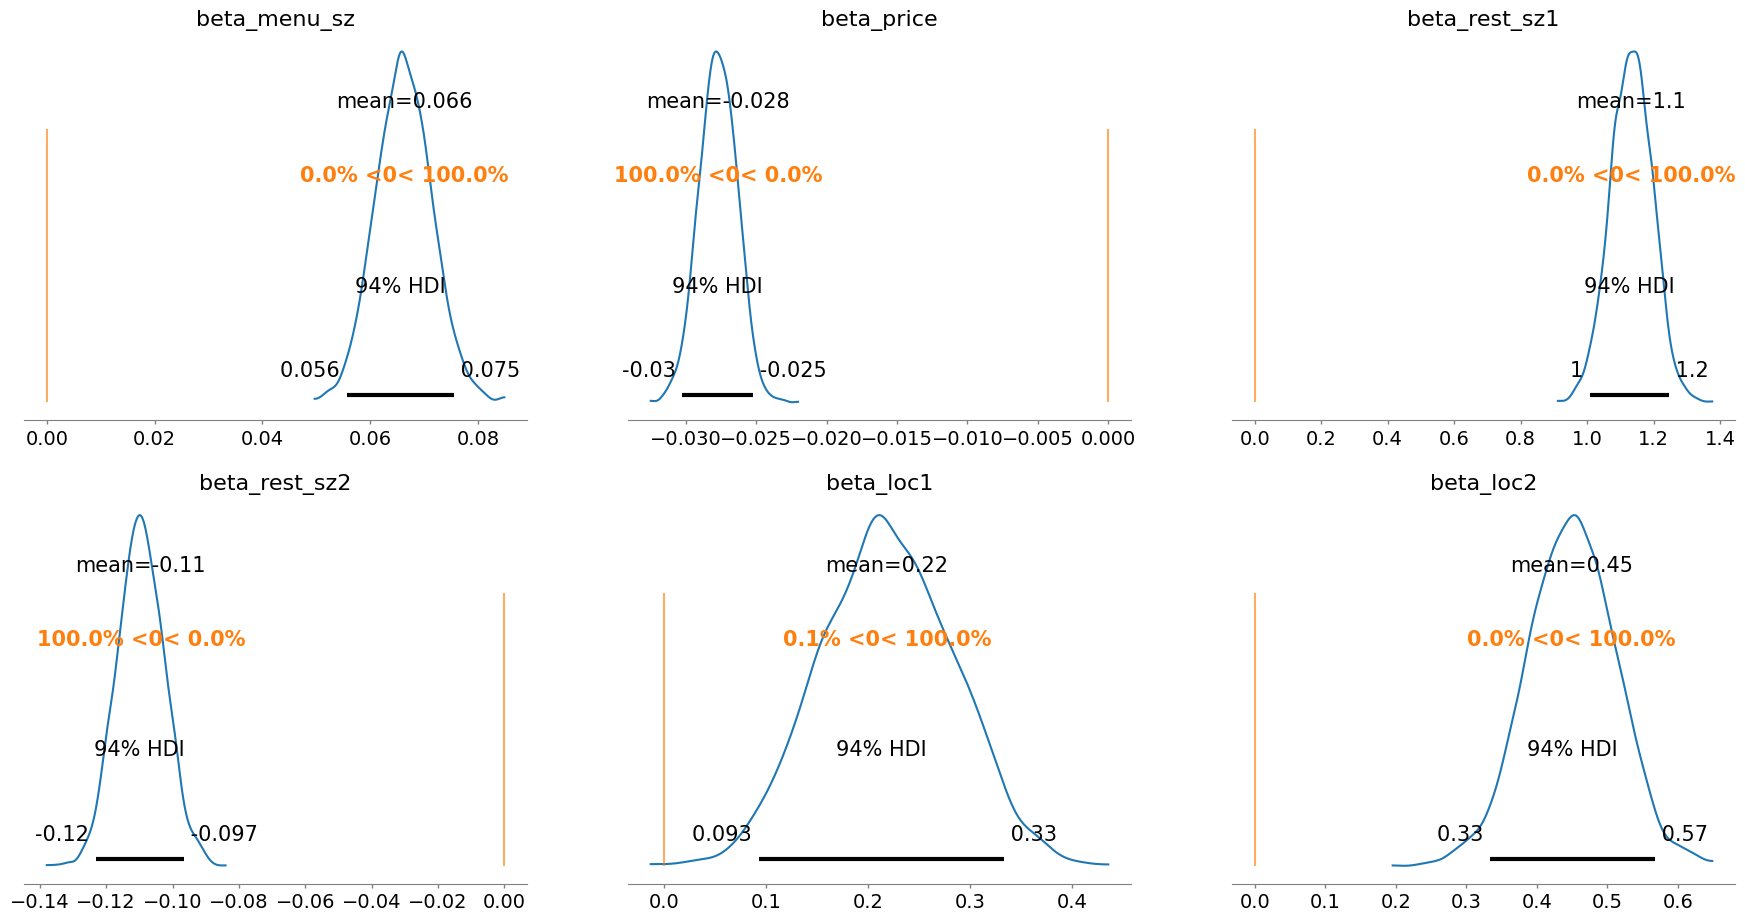

In [157]:
az.plot_posterior(idata_m1, 
                  ref_val=0,
                  var_names= ['beta_menu_sz', "beta_price", "beta_rest_sz1",
                              "beta_rest_sz2", "beta_loc1", "beta_loc2"])

<Axes: xlabel='choice_obs'>

C:\Users\L03552670\anaconda3\envs\TEC_FMDA\Lib\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\L03552670\anaconda3\envs\TEC_FMDA\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


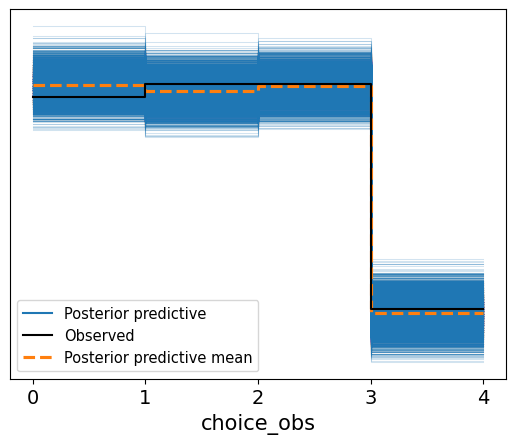

In [158]:
az.plot_ppc(idata_m1)